# Link budget: range and accuracy in metres

Turns the frequency-window shapes (see frequency_window) into numbers by
pinning the missing quantities: source level SL, noise NL, detection
threshold DT, and the drive ceiling. Inputs are tagged [P] physics,
[D] datasheet/bench, [E] environment, and are knobs at the top.

Every term is modelled, including the ones that are negligible or zero
under the current conditions (dielectric loss, multipath, shadowing,
bubble loss, electronics noise). They are kept explicit so this stands as
a record that they were considered, and so the same notebook is reusable
when conditions change (deeper, noisier, multipath channel) without
re-deriving anything.

Assumption stated, then checked below: ambient-noise-limited receiver.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- fixed ---
c = 1500.0      # m/s
rho = 1000.0    # kg/m^3
D = 0.085       # m, transverse resolving baseline (85x45 array)
Q = 10.0        # loaded (in-water) quality factor -> bandwidth B = f/Q

# --- candidate element: Steminc SMC1186T10410, 90 kHz radial tube ---
F0 = 90e3       # Hz   [D] resonant frequency
OD = 11e-3      # m    [D] outer diameter
ID = 8.6e-3     # m    [D] inner diameter
Lc = 10e-3      # m    [D] length
Cs = 5.0e-9     # F    [D] static capacitance
R_res = 150.0   # ohm  [D] in-air resonant resistance (datasheet upper bound) ~ mechanical loss
tan_d = 0.02    # -    [D] dielectric loss

t_wall = (OD - ID) / 2                       # m, electrode gap (radial poling)
A_rad = np.pi * OD * Lc                       # m^2, radiating (OD) surface
Vol = np.pi * (OD**2 - ID**2) / 4 * Lc        # m^3, ceramic volume

# --- material / mechanical limits (SM410 hard PZT, estimates [D]) ---
E_ac_max = 4e5     # V/m rms, max AC drive field (~4 kV/cm), depoling guard
S_max = 3e-4       # -, max dynamic strain before fracture risk (brittle ceramic)
d31 = 120e-12      # m/V, transverse piezo constant
q_heat_max = 2e6   # W/m^3, allowable CW dissipation density (water-cooled OD)
P_amp_max = 5.0    # W   [D] wearable amplifier real-power ceiling
duty = 1.0         # -   [D] transmit duty cycle (OOK); thermal scales with duty
depth = 0.0        # m   [E] operating depth; cavitation threshold rises with depth

# --- transmit drive + radiation split ---
V_drive = 20.0     # Vrms [D] amp output across the tuned element (operating point)
DI_tx = 0.0        # dB   [P] omni in-plane (radial mode)
eta_tx = 0.5       # -    [D] radiating fraction R_rad/(R_rad+R_mech); ~0.5 at ka~2
ka = 2 * np.pi * F0 / c * (OD / 2)            # ~2 -> efficient radiator, not ka<<1

R_mech = R_res                                # in-air loss resistance
R_rad = R_mech * eta_tx / (1 - eta_tx)        # radiation resistance from radiating fraction
R_in = R_mech + R_rad                         # in-water input resistance at resonance

# --- channel excess losses [E], 0 now, present for reuse ---
L_multipath = 0.0  # dB
L_shadow = 0.0     # dB, diver body shadowing
L_bubble = 0.0     # dB, exhaust plume
L_excess = L_multipath + L_shadow + L_bubble

# --- noise ---
wind = 5.0         # m/s [E] ~sea state 3
ship = 0.5         # 0-1 [E] moderate shipping
NL_elec = 25.0     # dB re 1 uPa^2/Hz [D] receiver electronics noise, input-referred

# --- detection + array ---
DT = 15.0                 # dB [D] in-band SNR for OOK noncoherent, BER ~1e-3 + margin
AG = 10 * np.log10(4)     # dB [P] 4-element receive array gain (uncorrelated noise)
BT = 100.0                # -  [D] time-bandwidth product per bearing estimate

# --- bearing systematic floor (SNR-independent) ---
floor_deg = 3.0  # deg [D/E] calibration + mutual coupling + multipath + near-field bias

# --- derived power terms ---
acoustic_power = lambda V: eta_tx * V**2 / R_in                     # W radiated
heat_mech = lambda V: (1 - eta_tx) * V**2 / R_in                    # W mechanical loss
heat_diel = lambda V: 2 * np.pi * F0 * Cs * V**2 * tan_d            # W dielectric loss
heat_power = lambda V: heat_mech(V) + heat_diel(V)                  # W total heat

## Candidate element: Steminc SMC1186T10410

90 kHz radial-mode tube, OD 11 / ID 8.6 / length 10 mm, wall 1.2 mm,
Cs = 5 nF, R_res < 150 ohm, tan d = 2%, SM410 hard PZT, omni in-plane.
Four at ~80 x 45 mm fit a 101 x 60 watch case.

SL is backed out of the part, not assumed:
- ka = 2 pi f a / c ~ 2: efficient radiator, not the ka<<1 collapse.
- in-air R_res ~ mechanical loss R_mech; radiating fraction eta sets
  R_rad = R_mech eta/(1-eta), so in-water input R_in = R_mech/(1-eta).
- tune the 5 nF out with ~0.6 mH; the amp drives R_in.
- P_elec = V^2 / R_in splits into radiated eta and heat (1-eta), plus a
  few-mW dielectric loss.
- SL = 170.8 + 10 log10(P_ac) + DI.

In [2]:
def thorp(f):  # f kHz -> dB/km
    return 0.11 * f**2 / (1 + f**2) + 44 * f**2 / (4100 + f**2) + 2.75e-4 * f**2 + 0.003


def noise_amb(f, w=wind, s=ship):  # f kHz -> dB re 1 uPa^2/Hz (Stojanovic)
    turb = 17 - 30 * np.log10(f)
    shp = 40 + 20 * (s - 0.5) + 26 * np.log10(f) - 60 * np.log10(f + 0.03)
    wnd = 50 + 7.5 * np.sqrt(w) + 20 * np.log10(f) - 40 * np.log10(f + 0.4)
    thm = -15 + 20 * np.log10(f)
    return 10 * np.log10(sum(10 ** (x / 10) for x in (turb, shp, wnd, thm)))


def noise_spec(f):  # ambient + electronics, dB re 1 uPa^2/Hz
    return 10 * np.log10(10 ** (noise_amb(f) / 10) + 10 ** (NL_elec / 10))


SL = 170.8 + 10 * np.log10(acoustic_power(V_drive)) + DI_tx
band = lambda f: f * 1e3 / Q
TL = lambda f, R: 20 * np.log10(R) + thorp(f) * R / 1000.0
snr_db = lambda f, R: SL - TL(f, R) - L_excess - (noise_spec(f) + 10 * np.log10(band(f))) + AG

f0k = F0 / 1e3
print(f"ka={ka:.2f}  R_in={R_in:.0f} ohm  P_ac={acoustic_power(V_drive):.2f} W  "
      f"P_heat={heat_power(V_drive)*1e3:.0f} mW (diel {heat_diel(V_drive)*1e3:.0f})  "
      f"SL={SL:.1f} dB")
print(f"ambient-limited check: NL_amb({f0k:.0f}k)={noise_amb(f0k):.1f} vs "
      f"NL_elec={NL_elec:.1f} dB re uPa^2/Hz -> "
      f"{'ambient-limited' if noise_amb(f0k) > NL_elec else 'ELECTRONICS-LIMITED'}")

ka=2.07  R_in=300 ohm  P_ac=0.67 W  P_heat=689 mW (diel 23)  SL=169.0 dB
ambient-limited check: NL_amb(90k)=29.2 vs NL_elec=25.0 dB re uPa^2/Hz -> ambient-limited


## Drive limits: why not just 100 V?

The drive ceiling is the minimum of five independent limits. Material
limits (field, fracture) sit far above the operating point; the binding
ones are thermal (continuous), cavitation (shallow, caps acoustic output),
and amplifier real power (wearable). Which one binds moves with duty cycle
and depth, so all five are computed and the smallest wins.

  thermal (CW*duty)      21 Vrms   <- binds
  cavitation             27 Vrms
  amp power              39 Vrms
  fracture              300 Vrms
  field (depole)        480 Vrms
operating V_drive=20 Vrms; CW ceiling=21 (thermal (CW*duty))


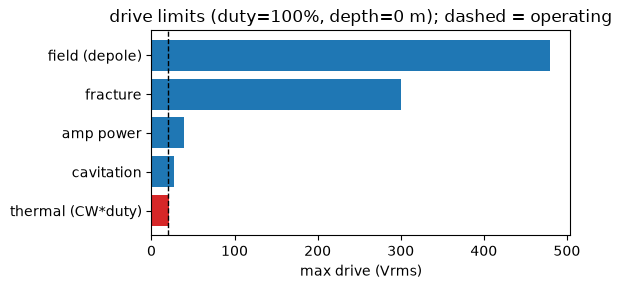

In [3]:
def drive_limits(duty=duty, depth=depth):
    p_cav = 1.013e5 * (1 + depth / 10.0)                       # Pa peak, ~1 atm + 1 atm/10 m
    g = (1 - eta_tx) / R_in + 2 * np.pi * F0 * Cs * tan_d      # heat per V^2
    return {
        "field (depole)": E_ac_max * t_wall,                  # V = E_max * gap
        "fracture": S_max * t_wall / (Q * d31),               # S = Q d31 V/t
        "thermal (CW*duty)": np.sqrt(q_heat_max * Vol / (duty * g)),
        "cavitation": np.sqrt(A_rad * p_cav**2 / (2 * rho * c) * R_in / eta_tx),
        "amp power": np.sqrt(P_amp_max * R_in),
    }


lims = drive_limits()
binder = min(lims, key=lims.get)
for k, v in sorted(lims.items(), key=lambda kv: kv[1]):
    print(f"  {k:18s} {v:6.0f} Vrms{'   <- binds' if k == binder else ''}")
print(f"operating V_drive={V_drive:.0f} Vrms; CW ceiling={lims[binder]:.0f} ({binder})")

plt.figure(figsize=(6, 3))
names = sorted(lims, key=lims.get)
plt.barh(names, [lims[n] for n in names],
         color=["C3" if n == binder else "C0" for n in names])
plt.axvline(V_drive, color="k", ls="--", lw=1)
plt.xlabel("max drive (Vrms)")
plt.title(f"drive limits (duty={duty:.0%}, depth={depth:.0f} m); dashed = operating")
plt.tight_layout()

The same model at low duty and depth shows the binding limit migrating:
at the surface CW it is thermal; low-duty OOK lifts the thermal ceiling
above cavitation, which then binds near the surface; with depth the
cavitation ceiling rises and amplifier power takes over.

In [4]:
for dy, dp in [(1.0, 0), (0.1, 0), (0.1, 20)]:
    L = drive_limits(dy, dp)
    b = min(L, key=L.get)
    print(f"  duty={dy:>4.0%} depth={dp:>2} m -> binds: {b:18s} at {L[b]:.0f} Vrms")

  duty=100% depth= 0 m -> binds: thermal (CW*duty)  at 21 Vrms
  duty= 10% depth= 0 m -> binds: cavitation         at 27 Vrms
  duty= 10% depth=20 m -> binds: amp power          at 39 Vrms


## Ambient noise

Stojanovic components plus the input-referred electronics floor. In our
band wind and thermal dominate; they cross near ~100 kHz.

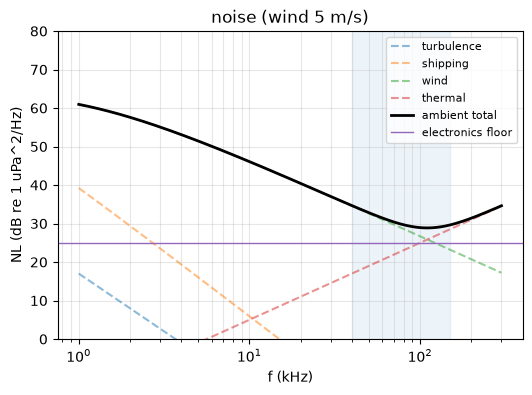

In [5]:
f = np.logspace(0, np.log10(300), 400)
plt.figure(figsize=(6, 4))
for name, fn in [
    ("turbulence", lambda f: 17 - 30 * np.log10(f)),
    ("shipping", lambda f: 40 + 26 * np.log10(f) - 60 * np.log10(f + 0.03)),
    ("wind", lambda f: 50 + 7.5 * np.sqrt(wind) + 20 * np.log10(f) - 40 * np.log10(f + 0.4)),
    ("thermal", lambda f: -15 + 20 * np.log10(f)),
]:
    plt.semilogx(f, fn(f), "--", alpha=0.5, label=name)
plt.semilogx(f, np.array([noise_amb(x) for x in f]), "k", lw=2, label="ambient total")
plt.axhline(NL_elec, color="C4", lw=1, label="electronics floor")
plt.axvspan(40, 150, alpha=0.08, color="C0")
plt.xlabel("f (kHz)")
plt.ylabel("NL (dB re 1 uPa^2/Hz)")
plt.title(f"noise (wind {wind:.0f} m/s)")
plt.ylim(0, 80)
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)

## Range, in metres

Reach = largest R with SNR(f, R) >= DT, sweeping the amp drive voltage.
Clean-water upper bound: the excess losses (multipath, shadow, bubble) are
zero here but subtract directly from SNR when set.

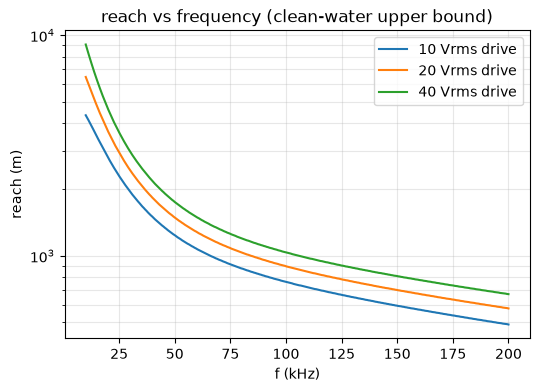

In [6]:
def reach(f, v_drive):
    sl = 170.8 + 10 * np.log10(eta_tx * v_drive**2 / R_in) + DI_tx
    R = np.logspace(0, 4, 5000)
    out = np.empty_like(f)
    for i, fi in enumerate(f):
        s = sl - TL(fi, R) - L_excess - (noise_spec(fi) + 10 * np.log10(band(fi))) + AG
        idx = np.where(s >= DT)[0]
        out[i] = R[idx[-1]] if idx.size else np.nan
    return out


f = np.linspace(10, 200, 300)
plt.figure(figsize=(6, 4))
for V in (10, 20, 40):
    plt.semilogy(f, reach(f, V), label=f"{V:.0f} Vrms drive")
plt.xlabel("f (kHz)")
plt.ylabel("reach (m)")
plt.title("reach vs frequency (clean-water upper bound)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)

## Accuracy, in degrees

Bearing error = quadrature sum of the SNR-limited CRLB and a systematic
floor. Inside reach the floor dominates, so accuracy is set by
calibration/coupling/multipath, not SNR or frequency, and sits at a few
degrees until the reach edge where SNR collapses.

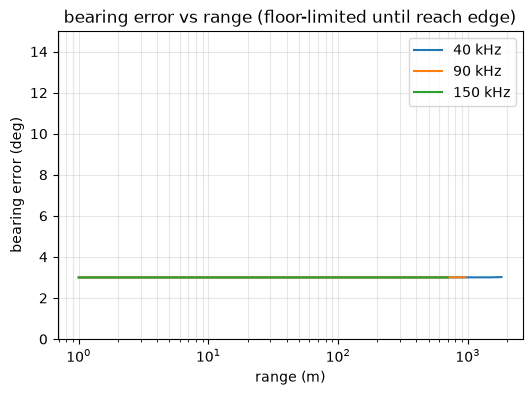

In [7]:
def bearing_deg(f, R, theta=0.0):
    snr = 10 ** (snr_db(f, R) / 10)
    sigma_tau = 1 / (2 * np.pi * band(f) * np.sqrt(2 * snr * BT))
    crlb = np.degrees(c * sigma_tau / (D * np.cos(theta))) / np.sqrt(2)
    return np.hypot(crlb, floor_deg)


R = np.logspace(0, np.log10(4000), 400)
plt.figure(figsize=(6, 4))
for fi in (40, 90, 150):
    y = bearing_deg(fi, R)
    y[snr_db(fi, R) < DT] = np.nan  # beyond reach
    plt.semilogx(R, y, label=f"{fi} kHz")
plt.xlabel("range (m)")
plt.ylabel("bearing error (deg)")
plt.title("bearing error vs range (floor-limited until reach edge)")
plt.ylim(0, 15)
plt.legend()
plt.grid(True, which="both", alpha=0.3)